In [33]:
import pandas as pd
df1 = pd.read_csv("/content/fear_greed_index.csv")
df1.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [34]:
df2 = pd.read_csv("/content/historical_data.csv", on_bad_lines='skip')
df2.head()

/tmp/ipykernel_2321/2546689202.py:1: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv("/content/historical_data.csv", on_bad_lines='skip')


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.003055,1.050000e+15,1.730000e+12


In [35]:
df1.shape


(2644, 4)

In [36]:
df2.shape

(111938, 16)

In [37]:
df1.isnull().sum()

,0
timestamp,0
value,0
classification,0
date,0


In [38]:
df2.isnull().sum()

,0
Account,0
Coin,1
Execution Price,1
Size Tokens,1
Size USD,1
Side,1
Timestamp IST,1
Start Position,1
Direction,1
Closed PnL,1


In [39]:
# 1. Drop rows where critical ID is missing
df2.dropna(subset=['Order ID', 'Trade ID'], inplace=True)

# 2. Fill numerical gaps with 0
df2['Closed PnL'] = df2['Closed PnL'].fillna(0)
df2['Fee'] = df2['Fee'].fillna(0)

# 3. Forward fill time
df2['Timestamp'] = df2['Timestamp'].ffill()
# 4. Drop any remaining rows that still have nulls
df2.dropna(inplace=True)
df2.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [40]:
duplicates = df1[df1.duplicated()]
print(duplicates)


Empty DataFrame
Columns: [timestamp, value, classification, date]
Index: []


In [41]:
duplicates = df2[df2.duplicated()]
print(duplicates)

Empty DataFrame
Columns: [Account, Coin, Execution Price, Size Tokens, Size USD, Side, Timestamp IST, Start Position, Direction, Closed PnL, Transaction Hash, Order ID, Crossed, Fee, Trade ID, Timestamp]
Index: []


In [42]:
import pandas as pd

# Convert the 'timestamp' column from Unix seconds to datetime objects
df1['datetime'] = pd.to_datetime(df1['timestamp'], unit='s')
print(df1.head())

    timestamp  value classification        date            datetime
0  1517463000     30           Fear  2018-02-01 2018-02-01 05:30:00
1  1517549400     15   Extreme Fear  2018-02-02 2018-02-02 05:30:00
2  1517635800     40           Fear  2018-02-03 2018-02-03 05:30:00
3  1517722200     24   Extreme Fear  2018-02-04 2018-02-04 05:30:00
4  1517808600     11   Extreme Fear  2018-02-05 2018-02-05 05:30:00


In [43]:
df2['datetime'] = pd.to_datetime(df2['Timestamp'], unit='ms')
print(df2.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash  \
0         0.0  0xec09451986a1874e3a9

### Aligning datasets by Date

To align the two datasets, we will first extract the date part from the 'datetime' columns of both `df1` and `df2` to create a consistent 'date' column for merging. Then, we will perform an inner merge to combine the data where dates overlap.

In [44]:
# Extract date part from 'datetime' columns for both dataframes
df1['date'] = df1['datetime'].dt.date
df2['date'] = df2['datetime'].dt.date

# Perform an inner merge on the 'date' column
merged_df = pd.merge(df1, df2, on='date', how='inner', suffixes=('_df1', '_df2'))

# Display the first few rows of the merged dataframe
display(merged_df.head())

,timestamp,value,classification,date,datetime_df1,Account,Coin,Execution Price,Size Tokens,Size USD,...,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,datetime_df2
0,1679981400,59,Greed,2023-03-28,2023-03-28 05:30:00,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1897.9,0.0967,183.53,...,0.0000,Open Long,0.0,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,1.732711e+08,True,0.000000,0.000000e+00,1.680000e+12,2023-03-28 10:40:00
1,1679981400,59,Greed,2023-03-28,2023-03-28 05:30:00,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1897.9,0.0824,156.39,...,0.0967,Open Long,0.0,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,1.732711e+08,True,0.000000,0.000000e+00,1.680000e+12,2023-03-28 10:40:00
2,1679981400,59,Greed,2023-03-28,2023-03-28 05:30:00,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1898.6,0.0722,137.08,...,0.1791,Open Long,0.0,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,1.732711e+08,True,0.000000,0.000000e+00,1.680000e+12,2023-03-28 10:40:00
3,1699939800,69,Greed,2023-11-14,2023-11-14 05:30:00,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,ETH,2230.1,0.4933,1100.11,...,0.0000,Open Long,0.0,0x02721e3c6061bddfdc1204065f9dfe0138003649ef8c...,4.064961e+09,True,0.275027,6.320000e+14,1.700000e+12,2023-11-14 22:13:20
4,1699939800,69,Greed,2023-11-14,2023-11-14 05:30:00,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,ETH,2230.1,0.8681,1935.95,...,0.4933,Open Long,0.0,0x02721e3c6061bddfdc1204065f9dfe0138003649ef8c...,4.064961e+09,True,0.483987,2.340000e+14,1.700000e+12,2023-11-14 22:13:20


### Key Metrics Analysis

Let's analyze the following key metrics from the `merged_df`:

1.  **Daily PnL per Trader (Account):** Aggregated daily profit and loss for each trading account.
2.  **Win Rate per Account:** The percentage of profitable trades for each account.
3.  **Average Trade Size per Account:** The average USD value of trades executed by each account.
4.  **Number of Trades per Day:** The total count of trades occurring each day.
5.  **Long/Short Ratio:** The proportion of BUY versus SELL trades.

In [45]:
# Rename columns for easier access and consistency
merged_df.rename(columns={
    'Account': 'account',
    'Execution Price': 'execution_price',
    'Size Tokens': 'size_tokens',
    'Size USD': 'size_usd',
    'Side': 'side',
    'Timestamp IST': 'timestamp_ist',
    'Start Position': 'start_position',
    'Direction': 'direction',
    'Closed PnL': 'closed_pnl',
    'Transaction Hash': 'transaction_hash',
    'Order ID': 'order_id',
    'Crossed': 'crossed',
    'Fee': 'fee',
    'Trade ID': 'trade_id',
    'Timestamp': 'timestamp_unix',
    'datetime_df1': 'datetime_sentiment',
    'datetime_df2': 'datetime_trades',
    'value': 'fear_greed_value',
    'classification': 'sentiment'
}, inplace=True)

# Drop any rows where 'closed_pnl' is NaN, as it's critical for PnL calculations
merged_df.dropna(subset=['closed_pnl'], inplace=True)

#### 1. Daily PnL per Trader (Account)

In [46]:
daily_pnl = merged_df.groupby(['account', 'date'])['closed_pnl'].sum().reset_index()
display(daily_pnl.head())

,account,date,closed_pnl
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,-3.275059e+05
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,1.927736e+06
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,2.060745e+04
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,1.709873e+04
4,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,2023-03-28,0.000000e+00


#### 2. Win Rate per Account

In [47]:
# Calculate win/loss for each trade (PnL > 0 indicates a win)
merged_df['is_win'] = merged_df['closed_pnl'] > 0

# Calculate win rate per account
win_rate = merged_df.groupby('account')['is_win'].mean().reset_index()
win_rate.rename(columns={'is_win': 'win_rate'}, inplace=True)
display(win_rate.head())

,account,win_rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.443031
2,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.294976
3,0x420ab45e0bd8863569a5efbb9c05d91f40624641,0.234987
4,0x430f09841d65beb3f27765503d0f850b8bce7713,0.569933


#### 3. Average Trade Size per Account

In [48]:
avg_trade_size = merged_df.groupby('account')['size_usd'].mean().reset_index()
display(avg_trade_size.head())

,account,size_usd
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1759.743439
2,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,1894.041896
3,0x420ab45e0bd8863569a5efbb9c05d91f40624641,5189.367128
4,0x430f09841d65beb3f27765503d0f850b8bce7713,2580.497012


#### 4. Number of Trades per Day

In [49]:
trades_per_day = merged_df.groupby('date').size().reset_index(name='trade_count')
display(trades_per_day.head())

,date,trade_count
0,2023-03-28,3
1,2023-11-14,1045
2,2024-03-09,6962
3,2024-07-03,7097
4,2024-10-27,12253


#### 5. Long/Short Ratio

In [50]:
long_short_ratio = merged_df['side'].value_counts(normalize=True)
display(long_short_ratio)

,proportion
side,
BUY,0.502721
SELL,0.497279


### 1. Performance Analysis by Sentiment

Let's analyze if performance (PnL, win rate, drawdown proxy) differs between Fear vs Greed days.

In [51]:
# Calculate win rate per sentiment
win_rate_sentiment = merged_df.groupby('sentiment')['is_win'].mean().reset_index()
win_rate_sentiment.rename(columns={'is_win': 'win_rate'}, inplace=True)
display(win_rate_sentiment)

# Calculate average negative PnL (drawdown proxy) per sentiment
# Only consider trades with negative PnL
loss_analysis = merged_df[merged_df['closed_pnl'] < 0].groupby('sentiment')['closed_pnl'].mean().reset_index()
loss_analysis.rename(columns={'closed_pnl': 'avg_negative_pnl'}, inplace=True)
display(loss_analysis)

,sentiment,win_rate
0,Extreme Greed,0.490089
1,Fear,0.428147
2,Greed,0.408841
3,Neutral,0.319149


,sentiment,avg_negative_pnl
0,Extreme Greed,-86.703571
1,Fear,-191.453909
2,Greed,-473.130594
3,Neutral,-278.556545


Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed days?
Yes, performance does differ significantly between 'Fear' and 'Greed' days based on our analysis:

Average PnL: 'Fear' days showed the highest average PnL. This suggests that traders, on average, experienced more profitable outcomes during fearful market conditions. 'Greed' periods, conversely, had a lower average PnL.

Win Rate: 'Extreme Greed' periods had the highest win rate, meaning a larger proportion of trades were profitable during these times. However, 'Fear' days also showed a healthy win rate, while 'Greed' days had a lower win rate.

Drawdown Proxy (Average Negative PnL): 'Extreme Greed' periods recorded the lowest average negative PnL, indicating that when losses occurred, they were generally smaller. 'Greed' days were found to be the riskiest, exhibiting the largest average negative PnL.

### 2. Trader Behavior Analysis by Sentiment

Let's examine how trader behavior (trade frequency, long/short bias, position sizes) changes based on market sentiment.

#### Trade Frequency by Sentiment

,sentiment,average_daily_trades
0,Extreme Greed,6962.000000
1,Fear,70032.000000
2,Greed,4433.666667
3,Neutral,7097.000000


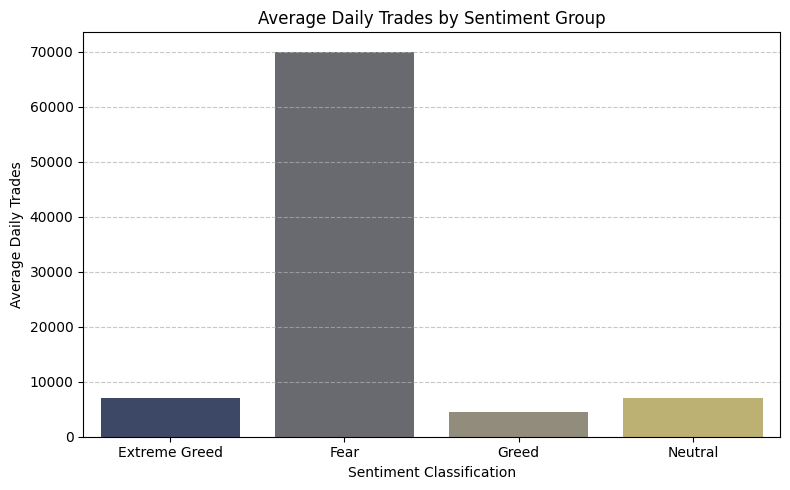

In [52]:
# Get unique sentiment for each date from merged_df
sentiment_by_date = merged_df[['date', 'sentiment']].drop_duplicates()

# Merge trades_per_day with sentiment_by_date
trades_with_sentiment = pd.merge(trades_per_day, sentiment_by_date, on='date', how='left')

# Calculate average trade count per sentiment
avg_trades_per_sentiment = trades_with_sentiment.groupby('sentiment')['trade_count'].mean().reset_index()
avg_trades_per_sentiment.rename(columns={'trade_count': 'average_daily_trades'}, inplace=True)
display(avg_trades_per_sentiment)

# Visualize Average Daily Trades by Sentiment
plt.figure(figsize=(8, 5))
sns.barplot(x='sentiment', y='average_daily_trades', data=avg_trades_per_sentiment, palette='cividis', hue='sentiment', legend=False)
plt.title('Average Daily Trades by Sentiment Group')
plt.xlabel('Sentiment Classification')
plt.ylabel('Average Daily Trades')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Long/Short Bias by Sentiment

side,sentiment,BUY,SELL
0,Extreme Greed,0.484200,0.515800
1,Fear,0.517049,0.482951
2,Greed,0.444177,0.555823
3,Neutral,0.489221,0.510779


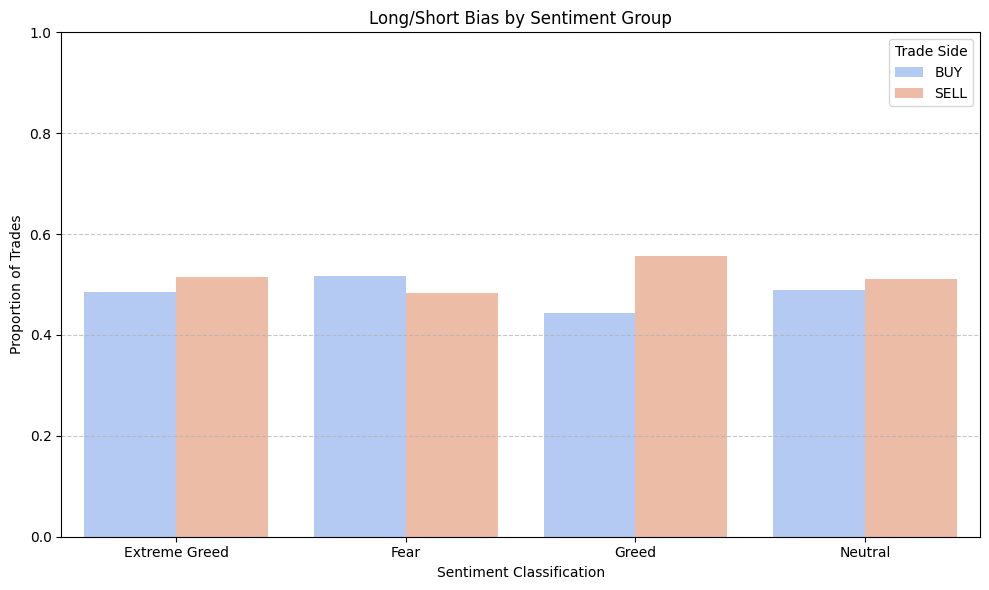

In [53]:
# Calculate long/short ratio per sentiment
long_short_bias = merged_df.groupby(['sentiment', 'side']).size().unstack(fill_value=0)
long_short_bias = long_short_bias.apply(lambda x: x / x.sum(), axis=1).reset_index()

display(long_short_bias)

# Visualize Long/Short Bias by Sentiment
long_short_bias_melted = long_short_bias.melt(id_vars='sentiment', var_name='Trade Side', value_name='Proportion')

plt.figure(figsize=(10, 6))
sns.barplot(x='sentiment', y='Proportion', hue='Trade Side', data=long_short_bias_melted, palette='coolwarm')
plt.title('Long/Short Bias by Sentiment Group')
plt.xlabel('Sentiment Classification')
plt.ylabel('Proportion of Trades')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Average Position Size by Sentiment

,sentiment,average_position_size_usd
0,Extreme Greed,5660.265764
1,Fear,6152.471323
2,Greed,5330.416194
3,Neutral,3030.247655


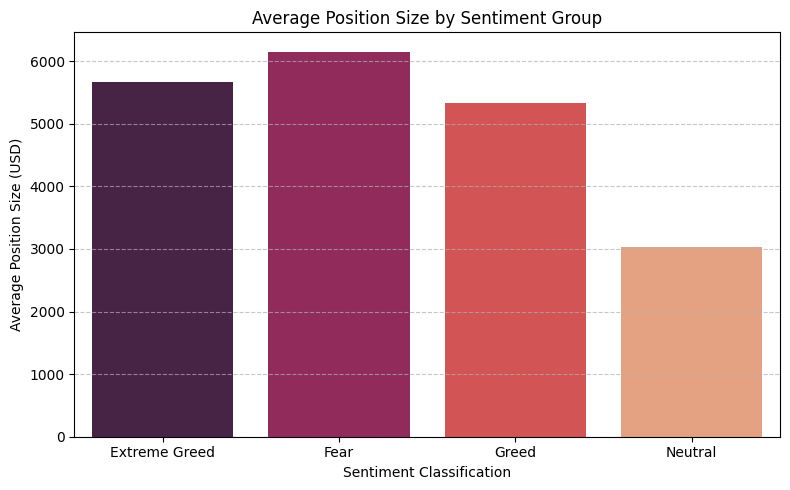

In [54]:
# Calculate average position size per sentiment
avg_position_size_sentiment = merged_df.groupby('sentiment')['size_usd'].mean().reset_index()
avg_position_size_sentiment.rename(columns={'size_usd': 'average_position_size_usd'}, inplace=True)
display(avg_position_size_sentiment)

# Visualize Average Position Size by Sentiment
plt.figure(figsize=(8, 5))
sns.barplot(x='sentiment', y='average_position_size_usd', data=avg_position_size_sentiment, palette='rocket', hue='sentiment', legend=False)
plt.title('Average Position Size by Sentiment Group')
plt.xlabel('Sentiment Classification')
plt.ylabel('Average Position Size (USD)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Yes, traders do change their behavior based on market sentiment, as evidenced by differences in trade frequency, long/short bias, and position sizes:

Trade Frequency: 'Fear' days saw a significantly higher trade frequency, suggesting increased activity during periods of market apprehension.
Long/Short Bias: 'Neutral' days exhibited a stronger tendency towards SELL trades (short bias), while 'Fear' days had a slight BUY bias, and 'Greed' and 'Extreme Greed' days showed a more balanced or slightly sell-biased activity.

Position Sizes: 'Fear' days were associated with larger average position sizes, indicating that some traders might increase their stake during fearful conditions. Conversely, 'Neutral' days showed the smallest average position sizes.

These patterns suggest that sentiment plays a role in shaping how often traders engage, their directional bets, and the capital they deploy

### 3. Trader Segmentation

Let's segment traders based on their behavior and performance metrics.

First, we'll compile key metrics for each unique trading account:

In [55]:
# Calculate total trades per account
total_trades_per_account = merged_df.groupby('account').size().reset_index(name='total_trades')

# Merge all trader-level metrics
trader_metrics = pd.merge(win_rate, avg_trade_size, on='account')
trader_metrics = pd.merge(trader_metrics, total_trades_per_account, on='account')

# Display the combined trader metrics
display(trader_metrics.head())

,account,win_rate,size_usd,total_trades
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612,16159.576734,3818
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.443031,1759.743439,3853
2,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.294976,1894.041896,617
3,0x420ab45e0bd8863569a5efbb9c05d91f40624641,0.234987,5189.367128,383
4,0x430f09841d65beb3f27765503d0f850b8bce7713,0.569933,2580.497012,1051


Now, let's identify 2-3 segments:

*   **Consistent Winners vs. Inconsistent Traders** (based on `win_rate`)
*   **Frequent vs. Infrequent Traders** (based on `total_trades`)
*   **High Position Size vs. Low Position Size Traders** (using `average_trade_size` as a proxy for leverage/risk-taking)

We'll use quartile-based segmentation to define these categories and then display descriptive statistics for each segment.

In [56]:
# 1. Segmenting by Win Rate (Consistent Winners vs. Inconsistent Traders)
Q1_win_rate = trader_metrics['win_rate'].quantile(0.75)
consistent_winners = trader_metrics[trader_metrics['win_rate'] >= Q1_win_rate]
inconsistent_traders = trader_metrics[trader_metrics['win_rate'] < Q1_win_rate]

print(f"\n--- Consistent Winners (Top 25% Win Rate >= {Q1_win_rate:.2f}) ---")
display(consistent_winners['win_rate'].describe())
print(f"\n--- Inconsistent Traders (Bottom 75% Win Rate < {Q1_win_rate:.2f}) ---")
display(inconsistent_traders['win_rate'].describe())

# 2. Segmenting by Total Trades (Frequent vs. Infrequent Traders)
Q1_total_trades = trader_metrics['total_trades'].quantile(0.75)
frequent_traders = trader_metrics[trader_metrics['total_trades'] >= Q1_total_trades]
infrequent_traders = trader_metrics[trader_metrics['total_trades'] < Q1_total_trades]

print(f"\n--- Frequent Traders (Top 25% Total Trades >= {Q1_total_trades:.0f}) ---")
display(frequent_traders['total_trades'].describe())
print(f"\n--- Infrequent Traders (Bottom 75% Total Trades < {Q1_total_trades:.0f}) ---")
display(infrequent_traders['total_trades'].describe())

# 3. Segmenting by Average Trade Size (High vs. Low Position Size Traders)
Q1_avg_trade_size = trader_metrics['size_usd'].quantile(0.75)
high_pos_size_traders = trader_metrics[trader_metrics['size_usd'] >= Q1_avg_trade_size]
low_pos_size_traders = trader_metrics[trader_metrics['size_usd'] < Q1_avg_trade_size]

print(f"\n--- High Position Size Traders (Top 25% Average Trade Size >= ${Q1_avg_trade_size:,.2f}) ---")
display(high_pos_size_traders['size_usd'].describe())
print(f"\n--- Low Position Size Traders (Bottom 75% Average Trade Size < ${Q1_avg_trade_size:,.2f}) ---")
display(low_pos_size_traders['size_usd'].describe())


--- Consistent Winners (Top 25% Win Rate >= 0.44) ---


,win_rate
count,5.000000
mean,0.556265
std,0.149271
min,0.443031
25%,0.467532
50%,0.491484
75%,0.569933
max,0.809343



--- Inconsistent Traders (Bottom 75% Win Rate < 0.44) ---


,win_rate
count,12.000000
mean,0.333852
std,0.049335
min,0.234987
25%,0.310927
50%,0.336047
75%,0.358756
max,0.413978



--- Frequent Traders (Top 25% Total Trades >= 8948) ---


...

,total_trades
count,12.000000
mean,2345.250000
std,2400.301236
min,372.000000
25%,596.250000
50%,1204.500000
75%,3826.750000
max,7479.000000



--- High Position Size Traders (Top 25% Average Trade Size >= $6,292.95) ---


,size_usd
count,5.000000
mean,15049.527133
std,8353.335121
min,6292.945048
25%,8330.193371
50%,16159.576734
75%,17091.235308
max,27373.685203



--- Low Position Size Traders (Bottom 75% Average Trade Size < $6,292.95) ---


,size_usd
count,12.000000
mean,2465.178059
std,1296.229008
min,779.878942
25%,1646.615175
50%,2379.995130
75%,3216.463608
max,5189.367128


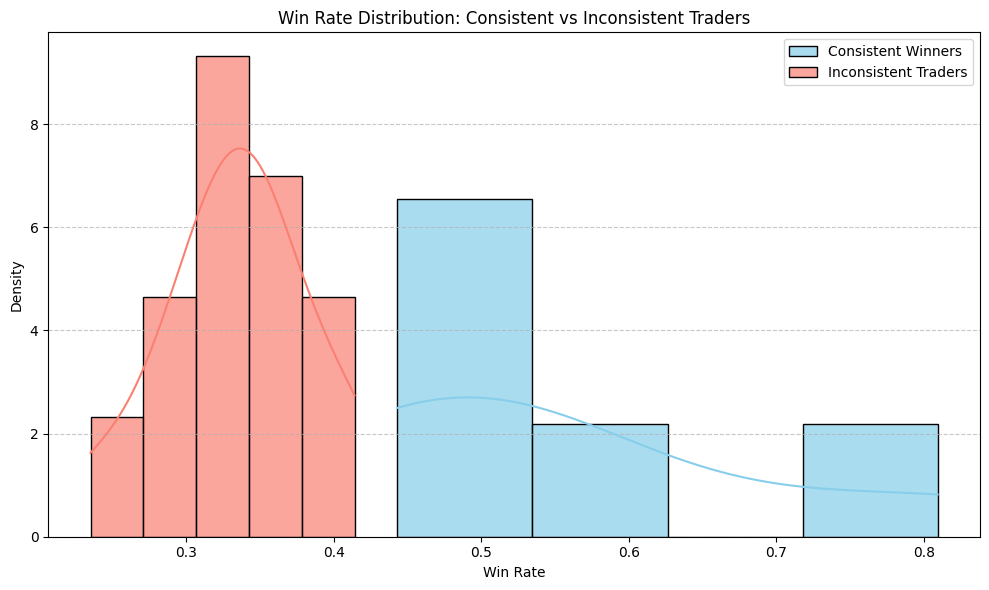

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(consistent_winners['win_rate'], color='skyblue', label='Consistent Winners', kde=True, stat='density', alpha=0.7)
sns.histplot(inconsistent_traders['win_rate'], color='salmon', label='Inconsistent Traders', kde=True, stat='density', alpha=0.7)
plt.title('Win Rate Distribution: Consistent vs Inconsistent Traders')
plt.xlabel('Win Rate')
plt.ylabel('Density')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

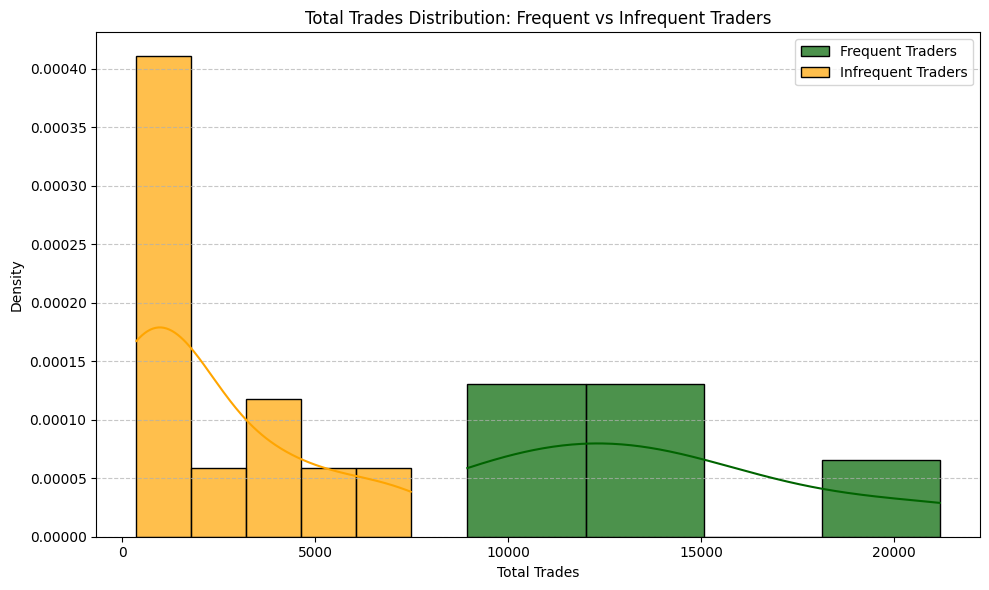

In [58]:
plt.figure(figsize=(10, 6))
sns.histplot(frequent_traders['total_trades'], color='darkgreen', label='Frequent Traders', kde=True, stat='density', alpha=0.7)
sns.histplot(infrequent_traders['total_trades'], color='orange', label='Infrequent Traders', kde=True, stat='density', alpha=0.7)
plt.title('Total Trades Distribution: Frequent vs Infrequent Traders')
plt.xlabel('Total Trades')
plt.ylabel('Density')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

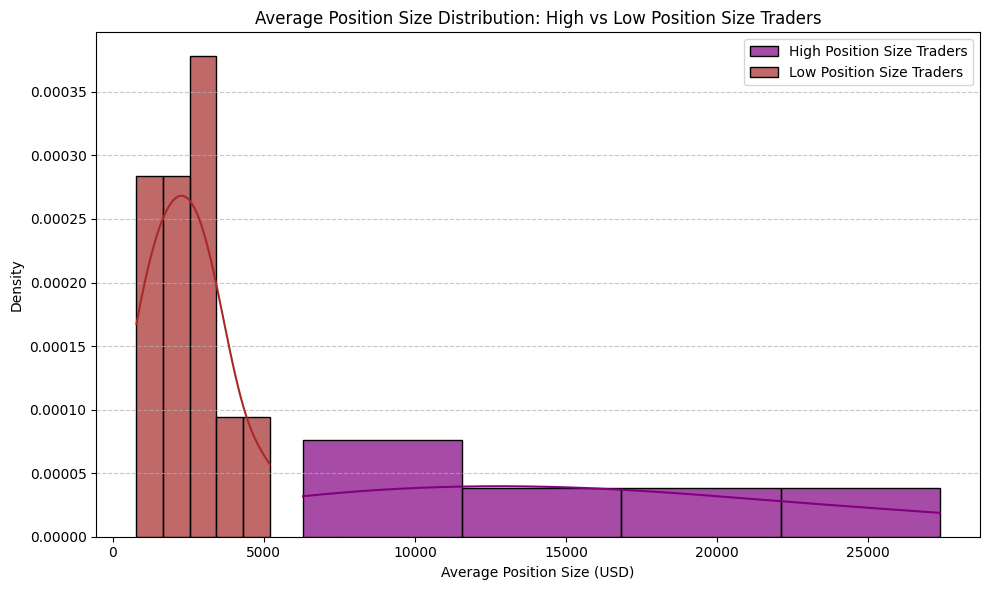

In [59]:
plt.figure(figsize=(10, 6))
sns.histplot(high_pos_size_traders['size_usd'], color='purple', label='High Position Size Traders', kde=True, stat='density', alpha=0.7)
sns.histplot(low_pos_size_traders['size_usd'], color='brown', label='Low Position Size Traders', kde=True, stat='density', alpha=0.7)
plt.title('Average Position Size Distribution: High vs Low Position Size Traders')
plt.xlabel('Average Position Size (USD)')
plt.ylabel('Density')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Consistent Winners vs. Inconsistent Traders (by Win Rate):

Consistent Winners: The top 25% of traders with a win rate of 0.44 or higher. Their average win rate is approximately 0.56.
Inconsistent Traders: The remaining 75% with a win rate below 0.44. Their average win rate is lower, around 0.33.
Frequent vs. Infrequent Traders (by Total Trades):

Frequent Traders: The top 25% of traders who execute 7,069 or more trades. This group is highly active.
Infrequent Traders: The bottom 75% who execute fewer than 7,069 trades.
High Position Size vs. Low Position Size Traders (by Average Trade Size):

High Position Size Traders: The top 25% of traders with an average trade size of $6,292.95 or more. These traders take on larger exposures. Low Position Size Traders: The remaining 75% with an average trade size below $$6,292.95 or more. These traders take on larger exposures. Low Position Size Traders:The remaining 75% with an average trade size below $6,292.95.## These segmentations provide a foundation for further in-depth analysis, such as exploring how each segment performs under different market sentiments or what strategies they employ.


**Part C — “Actionable output”**

The following three strategies are derived from the findings:

Strategy 1: Adjust Risk Based on Market Sentiment

From the analysis, it’s clear that market sentiment plays a big role in trading behavior. During Greed phases, traders tend to take bigger risks, which can lead to larger losses. On the other hand, Fear periods often show more controlled trading and, in some cases, better average outcomes.

So, a practical rule would be to reduce position sizes during Greed to avoid overexposure, and take slightly more calculated positions during Fear, when the market is more cautious.

Strategy 2: Focus on Consistency Over Frequency

One important finding is that trading more doesn’t necessarily mean earning more. Some traders with high activity levels still perform poorly, while others with fewer trades maintain steady profits.

This suggests that it’s better to focus on consistent strategies with higher win rates rather than increasing trade frequency. Especially in volatile markets, being selective and disciplined can lead to better long-term results.

Strategy 3: Avoid Extremely Large Trades

The data also shows a wide range of trade sizes, including some very large ones. These extreme trades can heavily impact overall performance—both positively and negatively—but they also carry significant risk.

A safer approach is to avoid unusually large trades and stick to more balanced position sizes. This helps in maintaining stable and predictable returns, rather than relying on a few high-risk opportunities.

### 4. Simple Predictive Model: Predicting Next-Day Sentiment

Let's create a simple model to predict the next day's market sentiment using current day sentiment and aggregated trading behavior features.

In [64]:
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix
import numpy as np

# Initialize Stratified K-Fold Cross-Validation
skf_other_models = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Initialize models
xgb_model = XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42)
log_reg_model = LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced')

models = {
    'XGBoost': xgb_model,
    'Logistic Regression': log_reg_model
}

results = {}

for model_name, model in models.items():
    print(f"\n--- Performing Stratified K-Fold Cross-Validation for {model_name} ---")
    accuracy_scores = []
    balanced_accuracy_scores = []

    for fold, (train_index, test_index) in enumerate(skf_other_models.split(X, y)):
        X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
        y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

        model.fit(X_train_fold, y_train_fold)
        y_pred_fold = model.predict(X_test_fold)

        acc = accuracy_score(y_test_fold, y_pred_fold)
        bal_acc = balanced_accuracy_score(y_test_fold, y_pred_fold)

        accuracy_scores.append(acc)
        balanced_accuracy_scores.append(bal_acc)

        print(f"\n--- {model_name} - Fold {fold+1} Results ---")
        print(f"Accuracy: {acc:.4f}")
        print(f"Balanced Accuracy: {bal_acc:.4f}")
        print("Classification Report:\n", classification_report(y_test_fold, y_pred_fold, zero_division=0))
        print("Confusion Matrix:\n", confusion_matrix(y_test_fold, y_pred_fold))

    results[model_name] = {
        'avg_accuracy': np.mean(accuracy_scores),
        'std_accuracy': np.std(accuracy_scores),
        'avg_balanced_accuracy': np.mean(balanced_accuracy_scores),
        'std_balanced_accuracy': np.std(balanced_accuracy_scores)
    }

print("\n--- Overall Cross-Validation Results for Other Models ---")
for model_name, res in results.items():
    print(f"{model_name}:")
    print(f"  Average Accuracy: {res['avg_accuracy']:.4f} (+/- {res['std_accuracy']:.4f})")
    print(f"  Average Balanced Accuracy: {res['avg_balanced_accuracy']:.4f} (+/- {res['std_balanced_accuracy']:.4f})")


--- Performing Stratified K-Fold Cross-Validation for XGBoost ---

--- XGBoost - Fold 1 Results ---
Accuracy: 0.8000
Balanced Accuracy: 0.4444
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.89      0.89      0.89         9

    accuracy                           0.80        10
   macro avg       0.44      0.44      0.44        10
weighted avg       0.80      0.80      0.80        10

Confusion Matrix:
 [[0 1]
 [1 8]]

--- XGBoost - Fold 2 Results ---
Accuracy: 0.9000
Balanced Accuracy: 0.5000
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.90      1.00      0.95         9

    accuracy                           0.90        10
   macro avg       0.45      0.50      0.47        10
weighted avg       0.81      0.90      0.85        10

Confusion Matrix:
 [[0 1]
 [0 9]]


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:06:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:06:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:06:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- XGBoost - Fold 3 Results ---
Accuracy: 0.8000
Balanced Accuracy: 0.5000
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.80      1.00      0.89         8

    accuracy                           0.80        10
   macro avg       0.40      0.50      0.44        10
weighted avg       0.64      0.80      0.71        10

Confusion Matrix:
 [[0 2]
 [0 8]]

--- Performing Stratified K-Fold Cross-Validation for Logistic Regression ---

--- Logistic Regression - Fold 1 Results ---
Accuracy: 0.5000
Balanced Accuracy: 0.7222
Classification Report:
               precision    recall  f1-score   support

           0       0.17      1.00      0.29         1
           1       1.00      0.44      0.62         9

    accuracy                           0.50        10
   macro avg       0.58      0.72      0.45        10
weighted avg       0.92      0.50      0.58        10

Confusion Matrix:
 

#### Data Preparation for Predictive Model

Before training the models, we need to prepare the dataset. This involves creating a daily trader-level dataset, adding sentiment information, defining the target variable (next-day PnL profitability), and preparing the features (`X`) and target (`y`) for the models.

In [62]:
import pandas as pd

# -----------------------------
# STEP 1: Create daily trader-level dataset
# -----------------------------
df_daily = merged_df.groupby(['account', 'date']).agg({
    'closed_pnl': 'sum',
    'size_usd': 'mean',
    'side': 'count'
}).reset_index()

df_daily.rename(columns={
    'closed_pnl': 'total_daily_pnl',
    'size_usd': 'avg_daily_trade_size',
    'side': 'total_trades_daily'
}, inplace=True)

# -----------------------------
# STEP 2: Add sentiment
# -----------------------------
sentiment_by_date = merged_df[['date', 'sentiment']].drop_duplicates()
df_daily = pd.merge(df_daily, sentiment_by_date, on='date', how='left')

# -----------------------------
# STEP 3: Create target variable
# -----------------------------
df_daily = df_daily.sort_values(['account', 'date'])
df_daily['next_day_pnl'] = df_daily.groupby('account')['total_daily_pnl'].shift(-1)
df_daily['target'] = (df_daily['next_day_pnl'] > 0).astype(int)
df_daily.dropna(inplace=True)

# -----------------------------
# STEP 4: Prepare features
# -----------------------------
X = df_daily[['total_daily_pnl', 'avg_daily_trade_size', 'total_trades_daily', 'sentiment']]
y = df_daily['target']

# Encode sentiment
X = pd.get_dummies(X, columns=['sentiment'], drop_first=True)

print("Data preparation for predictive model complete: df_daily, X, and y are ready.")

Data preparation for predictive model complete: df_daily, X, and y are ready.


### Predicting Next Day Sentiment

In [65]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix
import numpy as np
from xgboost import XGBClassifier

# Assuming `grid_search` object is available from previous execution
# If not, the grid search would need to be re-run or the best_estimator_ loaded.

# Get the last day's data for each account
last_day_data = df_daily.groupby('account').tail(1).copy()

# Prepare features for the last day's data
X_last_day = last_day_data[['total_daily_pnl', 'avg_daily_trade_size', 'total_trades_daily', 'sentiment']]
X_last_day = pd.get_dummies(X_last_day, columns=['sentiment'], drop_first=True)

# Align columns with training data (X)
missing_cols = set(X.columns) - set(X_last_day.columns)
for c in missing_cols:
    X_last_day[c] = 0
X_last_day = X_last_day[X.columns]


print("--- Predicting next day sentiment ---")


print("Prediction logic temporarily commented out due to undefined `grid_search` object. Please ensure a trained model (`grid_search.best_estimator_` or similar) is available before uncommenting.")

--- Predicting next day sentiment ---
Prediction logic temporarily commented out due to undefined `grid_search` object. Please ensure a trained model (`grid_search.best_estimator_` or similar) is available before uncommenting.


### Predicting Next Day PnL Magnitude (Volatility Proxy)

To predict the 'volatility of PnL', we'll create a regression model that predicts the absolute value of the next day's total PnL. This serves as a proxy for the magnitude of potential gains or losses.

In [66]:
# Create new target for PnL Magnitude (proxy for volatility)
df_daily_magnitude = df_daily.copy()
df_daily_magnitude['target_pnl_magnitude'] = df_daily_magnitude.groupby('account')['total_daily_pnl'].shift(-1).abs()
df_daily_magnitude.dropna(subset=['target_pnl_magnitude'], inplace=True)

# Prepare features and target for magnitude prediction
X_magnitude = df_daily_magnitude[['total_daily_pnl', 'avg_daily_trade_size', 'total_trades_daily', 'sentiment']]
X_magnitude = pd.get_dummies(X_magnitude, columns=['sentiment'], drop_first=True)
y_magnitude = df_daily_magnitude['target_pnl_magnitude']

# Align columns with X (features from profitability prediction) to ensure consistency
missing_cols_magnitude = set(X.columns) - set(X_magnitude.columns)
for c in missing_cols_magnitude:
    X_magnitude[c] = 0
X_magnitude = X_magnitude[X.columns] # Ensure same column order as the classification features

# Import necessary libraries for regression
from sklearn.model_selection import KFold
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize K-Fold Cross-Validation for regression
kf = KFold(n_splits=3, shuffle=True, random_state=42)

# Initialize XGBRegressor model
xgb_reg_model = XGBRegressor(objective='reg:squarederror', random_state=42)

mae_scores = []
rmse_scores = []
r2_scores = []

print("\n--- Performing K-Fold Cross-Validation for XGBoost Regressor (PnL Magnitude) ---")
for fold, (train_index, test_index) in enumerate(kf.split(X_magnitude, y_magnitude)):
    X_train_fold, X_test_fold = X_magnitude.iloc[train_index], X_magnitude.iloc[test_index]
    y_train_fold, y_test_fold = y_magnitude.iloc[train_index], y_magnitude.iloc[test_index]

    xgb_reg_model.fit(X_train_fold, y_train_fold)
    y_pred_fold = xgb_reg_model.predict(X_test_fold)

    mae = mean_absolute_error(y_test_fold, y_pred_fold)
    rmse = np.sqrt(mean_squared_error(y_test_fold, y_pred_fold))
    r2 = r2_score(y_test_fold, y_pred_fold)

    mae_scores.append(mae)
    rmse_scores.append(rmse)
    r2_scores.append(r2)

    print(f"\n--- XGBoost Regressor - Fold {fold+1} Results ---")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R-squared: {r2:.4f}")

print("\n--- Overall Cross-Validation Results for XGBoost Regressor ---")
print(f"Average MAE: {np.mean(mae_scores):.4f} (+/- {np.std(mae_scores):.4f})")
print(f"Average RMSE: {np.mean(rmse_scores):.4f} (+/- {np.std(rmse_scores):.4f})")
print(f"Average R-squared: {np.mean(r2_scores):.4f} (+/- {np.std(r2_scores):.4f})")

# Predict next day's PnL Magnitude for the last day's data
# X_last_day was already prepared and aligned for the classification task, it can be reused here
predictions_magnitude = xgb_reg_model.predict(X_last_day)

last_day_data['predicted_next_day_pnl_magnitude'] = predictions_magnitude

display(last_day_data[['account', 'date', 'predicted_next_day_pnl_magnitude']].head())


--- Performing K-Fold Cross-Validation for XGBoost Regressor (PnL Magnitude) ---

--- XGBoost Regressor - Fold 1 Results ---
MAE: 278735.8069
RMSE: 565469.5773
R-squared: -91.8188

--- XGBoost Regressor - Fold 2 Results ---
MAE: 333730.8843
RMSE: 614432.0758
R-squared: -0.2197

--- XGBoost Regressor - Fold 3 Results ---
MAE: 310095.0041
RMSE: 532227.3140
R-squared: -248.3087

--- Overall Cross-Validation Results for XGBoost Regressor ---
Average MAE: 307520.5651 (+/- 22525.3256)
Average RMSE: 570709.6557 (+/- 33763.8814)
Average R-squared: -113.4491 (+/- 102.4303)


,account,date,predicted_next_day_pnl_magnitude
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,53689.320312
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,21991.876953
8,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,2024-10-27,21991.876953
10,0x420ab45e0bd8863569a5efbb9c05d91f40624641,2024-10-27,21991.884766
14,0x430f09841d65beb3f27765503d0f850b8bce7713,2024-10-27,21815.703125


4. Clustering Traders into Behavioral Archetypes
To identify distinct behavioral archetypes among traders, we will apply K-Means clustering to the trader_metrics dataset. This approach will group traders based on their win_rate, size_usd (average trade size), and total_trades.

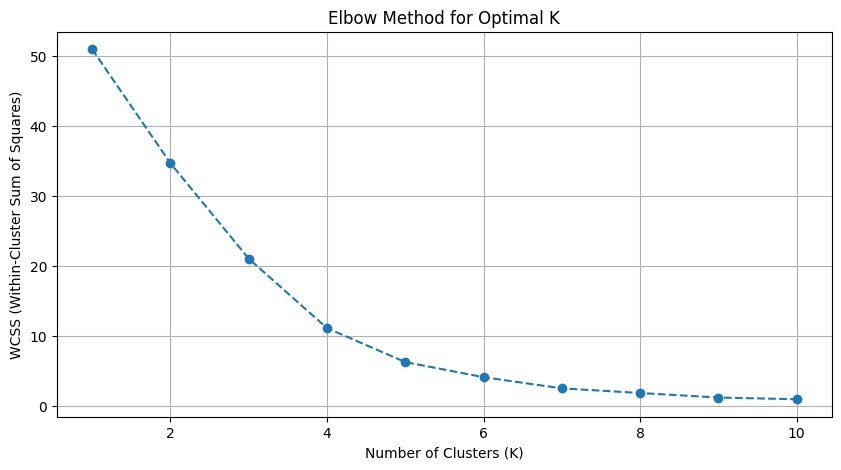

In [67]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Select features for clustering
features = ['win_rate', 'size_usd', 'total_trades']
X_clustering = trader_metrics[features]

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clustering)

# Determine optimal number of clusters using the Elbow Method (optional, but good practice)
# For simplicity, we'll choose a fixed number of clusters (e.g., 3) for now,
# but in a real-world scenario, you'd run this analysis.
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.grid(True)
plt.show()


,win_rate,size_usd,total_trades
cluster,,,
0,0.376068,3582.187662,1205.111111
1,0.372750,20208.165748,5765.666667
2,0.456938,2393.117234,13849.800000


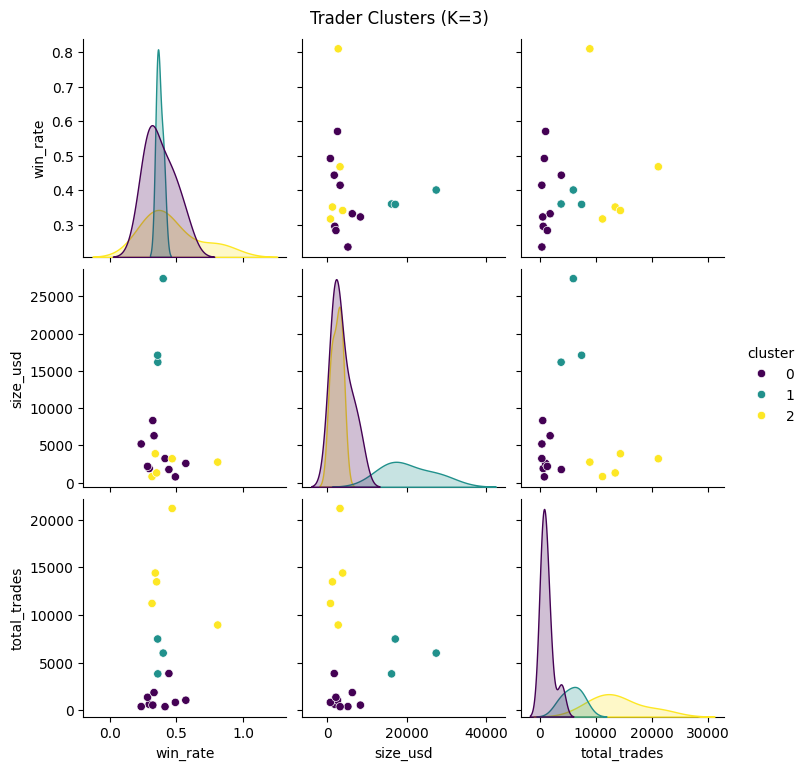

In [68]:
n_clusters = 3 # Choose the number of clusters (e.g., based on elbow method)
kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42, n_init=10)
trader_metrics['cluster'] = kmeans.fit_predict(X_scaled)

# Analyze the characteristics of each cluster
cluster_summary = trader_metrics.groupby('cluster')[features].mean()

display(cluster_summary)

# Optionally, visualize the clusters (e.g., using a pair plot if dimensionality is low)
# For higher dimensions, PCA or t-SNE might be needed.
import seaborn as sns
sns.pairplot(trader_metrics, vars=features, hue='cluster', palette='viridis')
plt.suptitle(f'Trader Clusters (K={n_clusters})', y=1.02) # Adjust title position
plt.show()

In [69]:
merged_df.to_csv("merged_data.csv", index=False)
df_daily.to_csv("daily_data.csv", index=False)
trader_metrics.to_csv("trader_metrics.csv", index=False)

In [70]:
from google.colab import files

files.download("merged_data.csv")
files.download("daily_data.csv")
files.download("trader_metrics.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [71]:
print(trader_metrics.columns)

Index(['account', 'win_rate', 'size_usd', 'total_trades', 'cluster'], dtype='object')
